# Quadruple tank: the infinite horizon vs a long finite horizon

The model is the canonical declared quadruple tank from
[`models/quad_tank.py`](models/quad_tank.py): Johansson's four-tank process
in its nonminimum-phase configuration, see the module for its construction.
Two cases of the same model. Case 1 runs five sampling steps (h = 10 s) with
the infinite-horizon terminal segment (`drto.infinite_horizon`) carrying the
tail, which deactivates the declared terminal cost since the tail owns the
cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.quad_tank import quad_tank
from plotting import plot_states, plot_controls

m1 = quad_tank(N=5, h=10)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpfygrudna.pyomo.nl...
pounce: wrote C:\

Parsed 309 vars, 281 cons, jac_nnz=1351, h_nnz=168 in 0.03s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:     1311
Number of nonzeros in inequality constraint Jacobian.:       40
Number of nonzeros in Lagrangian Hessian.............:      168

Total number of variables............................:      309
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      180
                     variables with only upper bounds:        0
Total number of equality constraints.................:      273
Total number of inequality constraints...............:        8
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        8
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 281, 'Number of variables': 309, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 1.1444878578186035}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

horizon,"t (ContinuousSet, 16 points)"
states,"x1 (free), x2 (free), x3 (free), x4 (free)"
dynamics,dx1[k] == - a1/A1*sqrt(2*g*x1[k]) + a3/A1*sqrt(2*g*x3[k]) + gamma/A1*u1[k] for k in t
dynamics,dx2[k] == - a2/A2*sqrt(2*g*x2[k]) + a4/A2*sqrt(2*g*x4[k]) + gamma/A2*u2[k] for k in t
dynamics,dx3[k] == - a3/A3*sqrt(2*g*x3[k]) + (1 - gamma)/A3*u2[k] for k in t
dynamics,dx4[k] == - a4/A4*sqrt(2*g*x4[k]) + (1 - gamma)/A4*u1[k] for k in t
controls,"u1 (piecewise_constant, free), u2 (piecewise_constant, free)"
tracking stage cost,cost[k] == (x1[k] - x1_ss)**2 + (x2[k] - x2_ss)**2 + (x3[k] - x3_ss)**2 + (x4[k] - x4_ss)**2 + (u1[k] - u1_ss)**2 + (u2[k] - u2_ss)**2 for k in OrderedScalarSet
terminal cost,term == (x1[50] - x1_ss)**2 + (x2[50] - x2_ss)**2 + (x3[50] - x3_ss)**2 + (x4[50] - x4_ss)**2
initial conditions,x1[0] == x1_hat
initial conditions,x2[0] == x2_hat


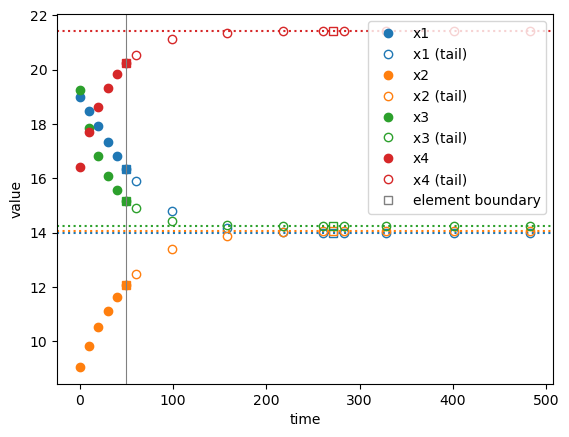

In [3]:
plot_states(m1, t_max=500)

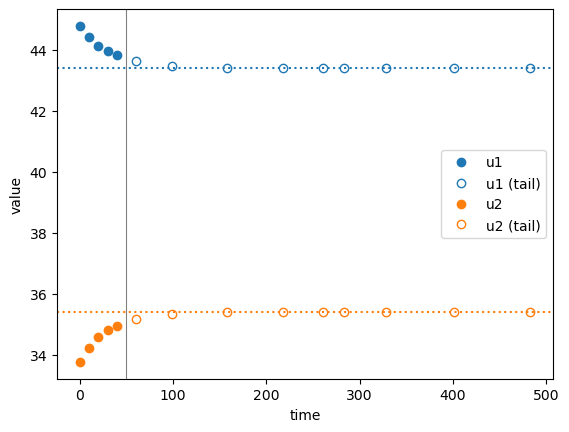

In [4]:
plot_controls(m1, t_max=500)

## Case 2: fifty samples, finite horizon with the terminal cost

In [5]:
m2 = quad_tank(N=50, h=10)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp3ciht4en.pyomo.nl...
pounce: wrote C:\

Parsed 1359 vars, 1259 cons, jac_nnz=5473, h_nnz=704 in 0.03s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:     5473
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      704

Total number of variables............................:     1359
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      704
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1259
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 1259, 'Number of variables': 1359, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 1.1469342708587646}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [6]:
drto.info(m2)

horizon,"t (ContinuousSet, 151 points)"
states,"x1 (free), x2 (free), x3 (free), x4 (free)"
dynamics,dx1[k] == - a1/A1*sqrt(2*g*x1[k]) + a3/A1*sqrt(2*g*x3[k]) + gamma/A1*u1[k] for k in t
dynamics,dx2[k] == - a2/A2*sqrt(2*g*x2[k]) + a4/A2*sqrt(2*g*x4[k]) + gamma/A2*u2[k] for k in t
dynamics,dx3[k] == - a3/A3*sqrt(2*g*x3[k]) + (1 - gamma)/A3*u2[k] for k in t
dynamics,dx4[k] == - a4/A4*sqrt(2*g*x4[k]) + (1 - gamma)/A4*u1[k] for k in t
controls,"u1 (piecewise_constant, free), u2 (piecewise_constant, free)"
tracking stage cost,cost[k] == (x1[k] - x1_ss)**2 + (x2[k] - x2_ss)**2 + (x3[k] - x3_ss)**2 + (x4[k] - x4_ss)**2 + (u1[k] - u1_ss)**2 + (u2[k] - u2_ss)**2 for k in OrderedScalarSet
terminal cost,term == (x1[500] - x1_ss)**2 + (x2[500] - x2_ss)**2 + (x3[500] - x3_ss)**2 + (x4[500] - x4_ss)**2
initial conditions,x1[0] == x1_hat
initial conditions,x2[0] == x2_hat


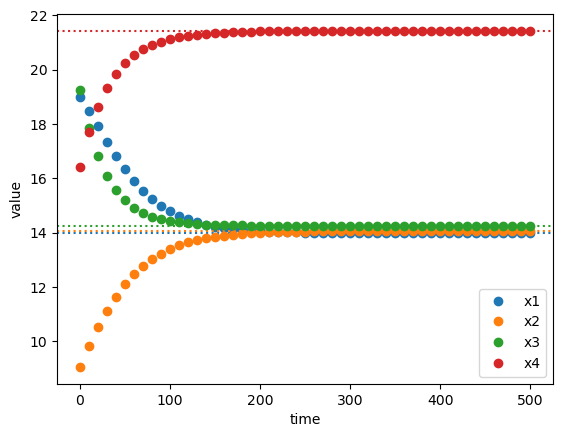

In [7]:
plot_states(m2, t_max=500)

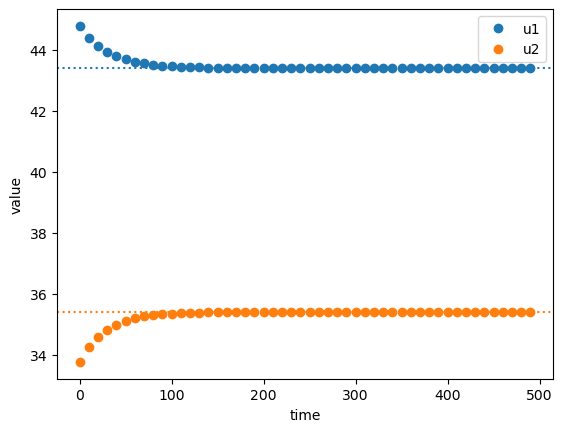

In [8]:
plot_controls(m2, t_max=500)